In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Navigate to the directory containing the .tar file
%cd /content/drive/MyDrive/RUGD Dataset/tarFolder/

# Unzip the .tar file
!tar -xvf rugd-DatasetNinja.tar

In [ ]:
import os

root = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train"

print(os.listdir(root))

['ann', 'img', 'meta']


In [ ]:
os.listdir("/content/drive/MyDrive/RUGD Dataset/tarFolder/train/meta")

['park-2_00001.png.json',
 'park-2_00006.png.json',
 'park-2_00011.png.json',
 'park-2_00016.png.json',
 'park-2_00021.png.json',
 'park-2_00026.png.json',
 'park-2_00031.png.json',
 'park-2_00036.png.json',
 'park-2_00041.png.json',
 'park-2_00046.png.json',
 'park-2_00051.png.json',
 'park-2_00056.png.json',
 'park-2_00061.png.json',
 'park-2_00066.png.json',
 'park-2_00071.png.json',
 'park-2_00076.png.json',
 'park-2_00081.png.json',
 'park-2_00086.png.json',
 'park-2_00091.png.json',
 'park-2_00096.png.json',
 'park-2_00101.png.json',
 'park-2_00106.png.json',
 'park-2_00111.png.json',
 'park-2_00116.png.json',
 'park-2_00121.png.json',
 'park-2_00126.png.json',
 'park-2_00131.png.json',
 'park-2_00136.png.json',
 'park-2_00141.png.json',
 'park-2_00146.png.json',
 'park-2_00151.png.json',
 'park-2_00156.png.json',
 'park-2_00161.png.json',
 'park-2_00166.png.json',
 'park-2_00171.png.json',
 'park-2_00176.png.json',
 'park-2_00181.png.json',
 'park-2_00186.png.json',
 'park-2_001

In [ ]:
import json
import os

meta_dir = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/ann"

file = os.listdir(meta_dir)[3]

with open(os.path.join(meta_dir, file)) as f:
    data = json.load(f)

print(data)

{'description': '', 'tags': [{'id': 16788340, 'tagId': 29910, 'name': 'park', 'value': 2, 'labelerLogin': 'inbox@datasetninja.com', 'createdAt': '2024-01-31T12:46:59.872Z', 'updatedAt': '2024-01-31T12:46:59.872Z'}], 'size': {'height': 550, 'width': 688}, 'objects': [{'id': 139293558, 'classId': 6512325, 'objectId': None, 'description': '', 'geometryType': 'bitmap', 'labelerLogin': 'inbox@datasetninja.com', 'createdAt': '2024-01-31T12:46:59.878Z', 'updatedAt': '2024-01-31T12:46:59.878Z', 'tags': [], 'classTitle': 'sky', 'bitmap': {'data': 'eJwBiAd3+IlQTkcNChoKAAAADUlIRFIAAAKwAAAAtwEDAAAA0BD/ZAAAAAZQTFRFAAAA////pdmf3QAAAAF0Uk5TAEDm2GYAAAcwSURBVHic1dvPat82HABweS5xYSEu7BJYiPMIv7HL7zDqFvYg3XroNbdlEGKXQHtbXmDPsirkkN7yCHPpYZeyOezi0d+sSbL1X/JPkv3r6BfSyInzqSLJkiwpAI3RFBCAZAOkQCyRo9cI9TRZDXdf4o/3XYpsQW8UbKOzvWBzhH7R2Pc3XmzeAC0k9qBECU02gwuqPq3PHGyBWoltdZYXQtaBsldZcu1gcQi2zUy2ZqkOZJuBHUsBFPhXOXex7yQWbHS2AGDN0kkns29AvnGy+D88ldhKZ3GcGV+hNxekXMCFR5W14LGppkbBkPtLzJLwY7+zsND4Uon68tUBTR47ylZmO3CoC42d3ZT

In [ ]:
import base64
import zlib
import numpy as np
from PIL import Image
import io

bitmap_data = data["objects"][0]["bitmap"]["data"]

decoded = base64.b64decode(bitmap_data)

decompressed = zlib.decompress(decoded)

mask = Image.open(io.BytesIO(decompressed))

mask_np = np.array(mask)

print(mask_np.shape)

(183, 688)


In [ ]:
import numpy as np

height = data["size"]["height"]
width = data["size"]["width"]

segmentation = np.zeros((height, width), dtype=np.uint8)

for i, obj in enumerate(data["objects"]):

    class_id = i + 1

    bitmap_data = obj["bitmap"]["data"]

    decoded = base64.b64decode(bitmap_data)
    decompressed = zlib.decompress(decoded)

    mask = Image.open(io.BytesIO(decompressed))
    mask = np.array(mask)

    y_origin, x_origin = obj["bitmap"]["origin"]

    mask_h, mask_w = mask.shape

    # Calculate the intersection dimensions to ensure the mask fits within segmentation
    y_start = y_origin
    y_end = min(y_origin + mask_h, height)
    x_start = x_origin
    x_end = min(x_origin + mask_w, width)

    # Crop the mask to the intersection dimensions
    cropped_mask = mask[0 : y_end - y_start, 0 : x_end - x_start]

    # Apply the cropped mask to the segmentation array
    if cropped_mask.size > 0: # Ensure the cropped mask is not empty
        segmentation[y_start:y_end, x_start:x_end][cropped_mask > 0] = class_id

In [ ]:
from PIL import Image
import numpy as np
import os

# The 'root' and 'file' variables are available in the kernel state from previous cells.
# root = '/content/drive/MyDrive/RUGD Dataset/tarFolder/train'
# file = 'park-2_00016.png.json'

image_filename = file.replace('.json', '')
img_path = os.path.join(root, 'img', image_filename)

image = Image.open(img_path)
image = np.array(image)

import tensorflow as tf

dataset = tf.data.Dataset.from_tensor_slices((image, segmentation))

dataset = dataset.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y))

dataset = dataset.batch(8)

In [ ]:
import os
import json
import base64
import zlib
import io

import numpy as np
from PIL import Image
import tensorflow as tf

In [ ]:
import os

root = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train"

ann_path = os.path.join(root, "ann")
img_path = os.path.join(root, "img")

In [ ]:
images = []
masks = []

In [ ]:
def create_rugd_generator(ann_path, img_path):
    def rugd_generator_impl():
        import os
        import json
        import base64
        import zlib
        import io

        import numpy as np
        from PIL import Image

        for file in os.listdir(ann_path):

            if not file.endswith(".json"):
                continue

            json_path = os.path.join(ann_path, file)

            with open(json_path) as f:
                data = json.load(f)

            height = data["size"]["height"]
            width = data["size"]["width"]

            segmentation = np.zeros((height, width), dtype=np.uint8)

            for i, obj in enumerate(data["objects"]):

                class_id = i + 1

                bitmap_data = obj["bitmap"]["data"]

                decoded = base64.b64decode(bitmap_data)
                decompressed = zlib.decompress(decoded)

                mask = Image.open(io.BytesIO(decompressed))
                mask = np.array(mask)

                y_origin, x_origin = obj["bitmap"]["origin"]

                mask_h, mask_w = mask.shape

                y_start = max(y_origin, 0)
                x_start = max(x_origin, 0)

                y_end = min(y_origin + mask_h, height)
                x_end = min(x_origin + mask_w, width)

                if y_start >= y_end or x_start >= x_end:
                    continue

                mask_y_start = y_start - y_origin
                mask_y_end = mask_y_start + (y_end - y_start)

                mask_x_start = x_start - x_origin
                mask_x_end = mask_x_start + (x_end - x_start)

                cropped_mask = mask[mask_y_start:mask_y_end, mask_x_start:mask_x_end]

                segmentation[y_start:y_end, x_start:x_end][cropped_mask > 0] = class_id

            image_filename = file.replace(".json", "")
            image_file = os.path.join(img_path, image_filename)

            image = Image.open(image_file)
            image = np.array(image)

            yield image, segmentation
    return rugd_generator_impl

In [ ]:
import tensorflow as tf

generator_callable = create_rugd_generator(ann_path, img_path)

dataset = tf.data.Dataset.from_generator(
    generator_callable,
    output_signature=(
        tf.TensorSpec(shape=(550,688,3), dtype=tf.uint8),
        tf.TensorSpec(shape=(550,688), dtype=tf.uint8),
    )
)

In [ ]:
dataset = dataset.map(
    lambda x,y: (tf.cast(x, tf.float32)/255.0, y)
)

dataset = dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
for img, mask in dataset.take(1):
    print(img.shape)
    print(mask.shape)

(8, 550, 688, 3)
(8, 550, 688)


To iterate through the entire `tf.data.Dataset`:

In [ ]:
for image_batch, mask_batch in dataset:
    print(f"Image Batch Shape: {image_batch.shape}, Mask Batch Shape: {mask_batch.shape}")
    # Add your training or evaluation logic here

Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3), Mask Batch Shape: (8, 550, 688)
Image Batch Shape: (8, 550, 688, 3

In [ ]:
for image_batch, mask_batch in dataset.take(1):
    print(np.unique(mask_batch))

[ 0  1  2  3  4  5  6  7  8  9 10]


In [ ]:
for image_batch, mask_batch in dataset.take(1):
    num_classes = len(np.unique(mask_batch))
    print("Number of classes:", num_classes)

Number of classes: 11


In [ ]:
mask = tf.expand_dims(mask, -1)

In [ ]:
import numpy as np
from PIL import Image
import os

# This line is added to define 'image' for demonstration purposes.
# In a typical workflow with tf.data.Dataset, images are processed within the dataset pipeline.
# The 'root' and 'file' variables are assumed to be defined from previous cells.
image_filename = file.replace('.json', '') # 'file' is from cell zApCI1H605A2, e.g., 'park-2_00016.png.json'
img_path = os.path.join(root, 'img', image_filename) # 'root' is from cell e9QgzdbM3kq8

image = Image.open(img_path)
image = np.array(image) # Convert to numpy array to match prior context

image = image / 255.0

In [ ]:
import os
import json

ann_path = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/ann"

classes = set()

for file in os.listdir(ann_path):
    if not file.endswith(".json"):
        continue

    with open(os.path.join(ann_path, file)) as f:
        data = json.load(f)

    for obj in data["objects"]:
        classes.add(obj["classTitle"])

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 23
Classes: {'asphalt', 'vehicle', 'gravel', 'pole', 'rock', 'building', 'sand', 'bush', 'tree', 'concrete', 'grass', 'sky', 'person', 'dirt', 'rock-bed', 'mulch', 'log', 'fence', 'bicycle', 'container', 'picnic-table', 'water', 'sign'}


In [ ]:
import os
import json
import base64
import zlib
import io
import numpy as np
from PIL import Image
import tensorflow as tf

# Paths
ann_path = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/ann"
img_path  = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/img"

TARGET_SIZE = (224, 224)  # Resize all images to this
BATCH_SIZE  = 8

obstacle_classes = {
    "rock", "rock-bed", "tree", "bush", "log",
    "person", "vehicle", "bicycle",
    "building", "fence", "pole", "sign",
    "container", "picnic-table", "water"
}

def compute_label(data):
    height = data["size"]["height"]
    width  = data["size"]["width"]
    total_pixels = height * width
    obstacle_pixels = 0

    for obj in data["objects"]:
        if obj["classTitle"] not in obstacle_classes:
            continue
        decoded      = base64.b64decode(obj["bitmap"]["data"])
        decompressed = zlib.decompress(decoded)
        mask         = np.array(Image.open(io.BytesIO(decompressed)))
        obstacle_pixels += np.sum(mask > 0)

    return 1 if (obstacle_pixels / total_pixels) >= 0.30 else 0

def sample_generator():
    for file in os.listdir(ann_path):
        if not file.endswith(".json"):
            continue

        json_file = os.path.join(ann_path, file)
        image_file = os.path.join(img_path, file.replace(".json", ""))

        if not os.path.exists(image_file):
            print("Missing image:", image_file)
            continue

        with open(json_file) as f:
            data = json.load(f)

        label = compute_label(data)

        # Load + resize here, one at a time — never accumulate in a list
        image = Image.open(image_file).convert("RGB").resize(TARGET_SIZE)
        image = np.array(image, dtype=np.float32) / 255.0

        yield image, label  # stream one sample at a time

# Build dataset from generator — no giant numpy array needed
dataset = tf.data.Dataset.from_generator(
    sample_generator,
    output_signature=(
        tf.TensorSpec(shape=(*TARGET_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(),               dtype=tf.int32),
    )
)

dataset = (
    dataset
    .shuffle(buffer_size=200)       # smaller buffer = less RAM
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)     # overlap I/O with GPU compute
)

dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
import tensorflow as tf

dataset = dataset.shuffle(buffer_size=1000, seed=42)

total_size = 4434
train_size = int(0.8 * total_size)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

print(train_ds)
print(val_ds)


<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_SkipDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


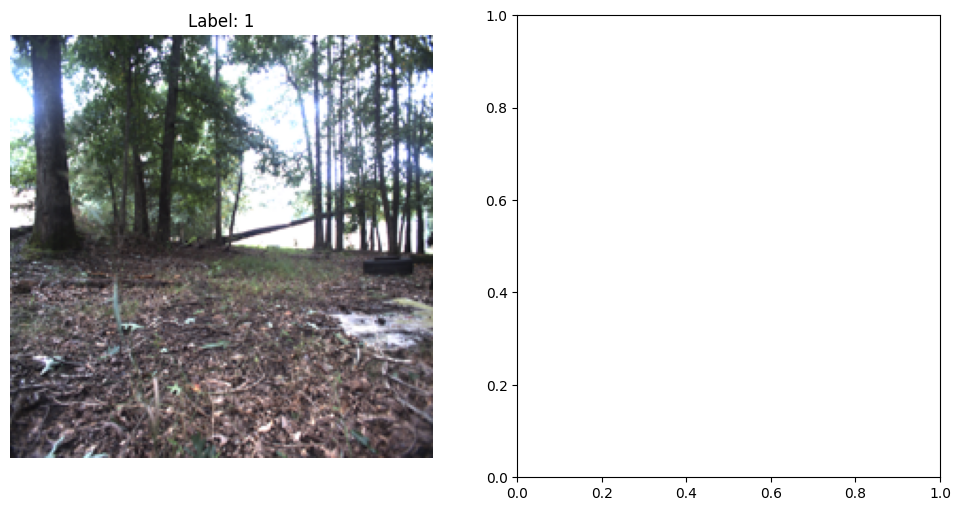

In [ ]:
import matplotlib.pyplot as plt

image, label = next(iter(train_ds.unbatch().take(1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image.numpy())  # remove .astype("uint8")
axes[0].set_title(f"Label: {label.numpy()}")
axes[0].axis("off")

plt.show()

In [44]:
#compute label

ann_path   = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/ann"
img_path   = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/img"
cache_file = "/content/drive/MyDrive/RUGD Dataset/labels_cache.pkl"

obstacle_classes = {
    "rock", "rock-bed", "tree", "bush", "log",
    "person", "vehicle", "bicycle",
    "building", "fence", "pole", "sign",
    "container", "picnic-table", "water"
}

if not os.path.exists(cache_file):
    import base64, zlib, io, json, pickle
    import numpy as np
    from PIL import Image

    def compute_label(data):
        height = data["size"]["height"]
        width  = data["size"]["width"]

        # Only look at the bottom 1/4 of the image — immediately in front of the robot
        path_region_start = int(height * 0.75)
        path_pixels       = (height * 0.25) * width
        obstacle_in_path  = 0

        for obj in data["objects"]:
            if obj["classTitle"] not in obstacle_classes:
                continue
            decoded      = base64.b64decode(obj["bitmap"]["data"])
            decompressed = zlib.decompress(decoded)
            mask         = np.array(Image.open(io.BytesIO(decompressed)))

            origin_y     = obj["bitmap"]["origin"][1]
            mask_in_path = mask[max(0, path_region_start - origin_y):, :]
            obstacle_in_path += np.sum(mask_in_path > 0)

        ratio = obstacle_in_path / path_pixels
        return 0 if ratio >= 0.01 else 1  # 40% of the immediate path must be blocked

    label_map = {}
    files = [f for f in os.listdir(ann_path) if f.endswith(".json")]
    for i, file in enumerate(files):
        with open(os.path.join(ann_path, file)) as f:
            data = json.load(f)
        label_map[file] = compute_label(data)
        if i % 100 == 0:
            print(f"Progress: {i}/{len(files)}")

    with open(cache_file, "wb") as f:
        pickle.dump(label_map, f)
    print("Labels cached to Google Drive")

else:
    import pickle # Import pickle for loading
    with open(cache_file, "rb") as f:
        label_map = pickle.load(f)
    print(f"Loaded {len(label_map)} labels from cache")

# ---- Check class balance --------------------------------------------------

count_0 = sum(1 for l in label_map.values() if l == 0)
count_1 = sum(1 for l in label_map.values() if l == 1)
print(f"Class 0 (non-traversable): {count_0} ({100 * count_0 / len(label_map):.1f}%)")
print(f"Class 1 (traversable):     {count_1} ({100 * count_1 / len(label_map):.1f}%)")

Progress: 0/4779
Progress: 100/4779
Progress: 200/4779
Progress: 300/4779
Progress: 400/4779
Progress: 500/4779
Progress: 600/4779
Progress: 700/4779
Progress: 800/4779
Progress: 900/4779
Progress: 1000/4779
Progress: 1100/4779
Progress: 1200/4779
Progress: 1300/4779
Progress: 1400/4779
Progress: 1500/4779
Progress: 1600/4779
Progress: 1700/4779
Progress: 1800/4779
Progress: 1900/4779
Progress: 2000/4779
Progress: 2100/4779
Progress: 2200/4779
Progress: 2300/4779
Progress: 2400/4779
Progress: 2500/4779
Progress: 2600/4779
Progress: 2700/4779
Progress: 2800/4779
Progress: 2900/4779
Progress: 3000/4779
Progress: 3100/4779
Progress: 3200/4779
Progress: 3300/4779
Progress: 3400/4779
Progress: 3500/4779
Progress: 3600/4779
Progress: 3700/4779
Progress: 3800/4779
Progress: 3900/4779
Progress: 4000/4779
Progress: 4100/4779
Progress: 4200/4779
Progress: 4300/4779
Progress: 4400/4779
Progress: 4500/4779
Progress: 4600/4779
Progress: 4700/4779
Labels cached to Google Drive
Class 0 (non-traversab

In [46]:
import random
from sklearn.model_selection import train_test_split

class0_files = [f for f in all_files if label_map.get(f) == 0]
class1_files = [f for f in all_files if label_map.get(f) == 1]

c0_train, c0_temp = train_test_split(class0_files, test_size=0.2, random_state=42)
c0_val,   c0_test = train_test_split(c0_temp,      test_size=0.5, random_state=42)

c1_train, c1_temp = train_test_split(class1_files, test_size=0.2, random_state=42)
c1_val,   c1_test = train_test_split(c1_temp,      test_size=0.5, random_state=42)

train_files = c0_train + c1_train
val_files   = c0_val   + c1_val
test_files  = c0_test  + c1_test

random.shuffle(train_files)
random.shuffle(val_files)
random.shuffle(test_files)

print(f"Train - Class 0: {len(c0_train)}, Class 1: {len(c1_train)}")
print(f"Val   - Class 0: {len(c0_val)},   Class 1: {len(c1_val)}")
print(f"Test  - Class 0: {len(c0_test)},  Class 1: {len(c1_test)}")

Train - Class 0: 578, Class 1: 3244
Val   - Class 0: 72,   Class 1: 406
Test  - Class 0: 73,  Class 1: 406


In [33]:
import base64, zlib, io, json

files = [f for f in os.listdir(ann_path) if f.endswith(".json")]
ratios = []

for file in files:
    with open(os.path.join(ann_path, file)) as f:
        data = json.load(f)
    height = data["size"]["height"]
    width  = data["size"]["width"]
    path_region_start = int(height * 0.75)
    path_pixels = (height * 0.25) * width
    obstacle_in_path = 0
    for obj in data["objects"]:
        if obj["classTitle"] not in obstacle_classes:
            continue
        decoded = base64.b64decode(obj["bitmap"]["data"])
        mask = np.array(Image.open(io.BytesIO(zlib.decompress(decoded))))
        origin_y = obj["bitmap"]["origin"][1]
        mask_in_path = mask[max(0, path_region_start - origin_y):, :]
        obstacle_in_path += np.sum(mask_in_path > 0)
    ratios.append(obstacle_in_path / path_pixels)

ratios = np.array(ratios)
print(f"Min:    {ratios.min():.3f}")
print(f"Max:    {ratios.max():.3f}")
print(f"Mean:   {ratios.mean():.3f}")
print(f"Median: {np.median(ratios):.3f}")
print(f"\nImages with ratio > 0.01: {np.sum(ratios > 0.01)}")
print(f"Images with ratio > 0.05: {np.sum(ratios > 0.05)}")
print(f"Images with ratio > 0.10: {np.sum(ratios > 0.10)}")
print(f"Images with ratio > 0.20: {np.sum(ratios > 0.20)}")
print(f"Images with ratio > 0.40: {np.sum(ratios > 0.40)}")

Min:    0.000
Max:    1.004
Mean:   0.024
Median: 0.000

Images with ratio > 0.01: 723
Images with ratio > 0.05: 468
Images with ratio > 0.10: 303
Images with ratio > 0.20: 174
Images with ratio > 0.40: 68


In [43]:
import os

cache_file = "/content/drive/MyDrive/RUGD Dataset/labels_cache.pkl"
os.remove(cache_file)
print("Cache deleted — re-run the cell to recompute labels")

Cache deleted — re-run the cell to recompute labels


In [39]:
import tensorflow as tf
import os
import numpy as np
from PIL import Image
import pickle
import math

# ---- Model ----------------------------------------------------------------

def make_tinyvgg(num_classes: int, input_shape: tuple = (224, 224, 3)) -> tf.keras.Model:
    return tf.keras.Sequential([
        # Block 1
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu", input_shape=input_shape),
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPool2D(2),

        # Block 2
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu"),
        tf.keras.layers.Conv2D(10, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPool2D(2),

        # Classifier
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="TinyVGG")

# ---- Dataset conversion ---------------------------------------------------

def rugd_split_to_tf(file_list, label_map, ann_path, img_path, image_size=(92, 92), batch_size=8, shuffle=False):
    """Convert RUGD file list to a tf.data.Dataset."""

    def gen():
        for i, file in enumerate(file_list):
            if i % 3 == 0:
                continue
            image_file = os.path.join(img_path, file.replace(".json", ""))
            if not os.path.exists(image_file):
                continue
            image = Image.open(image_file).convert("L").resize(image_size)
            image = np.array(image, dtype=np.float32) / 255.0
            image = image[..., np.newaxis]
            label = label_map[file]
            yield image, label

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(*image_size, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(),               dtype=tf.int32),
        )
    )
    if shuffle:
        ds = ds.shuffle(1024)
    return ds.repeat().batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ---- Load label cache -----------------------------------------------------

ann_path   = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/ann"
img_path   = "/content/drive/MyDrive/RUGD Dataset/tarFolder/train/img"
cache_file = "/content/drive/MyDrive/RUGD Dataset/labels_cache.pkl"

with open(cache_file, "rb") as f:
    label_map = pickle.load(f)

print(f"Loaded {len(label_map)} labels from cache")

# ---- Split files ----------------------------------------------------------

all_files = [f for f in os.listdir(ann_path) if f.endswith(".json")]
total     = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files = all_files[:train_end]
val_files   = all_files[train_end:val_end]
test_files  = all_files[val_end:]

train_ds = rugd_split_to_tf(train_files, label_map, ann_path, img_path, shuffle=True)
val_ds   = rugd_split_to_tf(val_files,   label_map, ann_path, img_path)
test_ds  = rugd_split_to_tf(test_files,  label_map, ann_path, img_path)

# ---- Class weights --------------------------------------------------------

total   = len(label_map)
count_0 = sum(1 for l in label_map.values() if l == 0)
count_1 = sum(1 for l in label_map.values() if l == 1)

class_weight = {
    0: total / (2 * count_0),
    1: total / (2 * count_1),
}
print("Class weights:", class_weight)

# ---- Training -------------------------------------------------------------

num_classes = 2

model = make_tinyvgg(num_classes=num_classes, input_shape=(92, 92, 1))
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=["accuracy"],
)
model.summary()

train_steps = math.ceil((train_end * 2/3) / 8)
val_steps   = math.ceil(((val_end - train_end) * 2/3) / 8)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    class_weight=class_weight,
)

Loaded 4779 labels from cache
Class weights: {0: 35.13970588235294, 1: 0.5072171513479091}


Model: "TinyVGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 92, 92, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 92, 92, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 46, 46, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 46, 46, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 46, 46, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5290)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │        10,582 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,412 (52.39 KB)

 Trainable params: 13,412 (52.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 125s 310ms/step - accuracy: 0.4898 - loss: 0.7295 - val_accuracy: 0.0094 - val_loss: 0.7654
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 90s 282ms/step - accuracy: 0.1771 - loss: 0.8684 - val_accuracy: 0.0437 - val_loss: 0.7180
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 88s 276ms/step - accuracy: 0.1920 - loss: 0.7117 - val_accuracy: 0.1688 - val_loss: 0.7160
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 88s 276ms/step - accuracy: 0.3323 - loss: 0.9454 - val_accuracy: 0.6969 - val_loss: 0.6842
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 138s 432ms/step - accuracy: 0.3268 - loss: 0.7227 - val_accuracy: 0.0188 - val_loss: 0.7294
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 82s 256ms/step - accuracy: 0.2551 - loss: 0.7135 - val_accuracy: 0.2219 - val_loss: 0.8109
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 138s 435ms/step - accuracy: 0.6258 - loss: 0.6265 - val_accuracy: 0.4531 - val_loss: 0.8062
Epoch 8/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 85s 267ms/step - accuracy: 0.7606 - loss

In [23]:
from collections import Counter
import pickle # Added import for pickle

# Define cache_file path to load label_map
cache_file = "/content/drive/MyDrive/RUGD Dataset/labels_cache.pkl"

# Load label_map from cache
try:
    with open(cache_file, "rb") as f:
        label_map = pickle.load(f)
    print(f"Loaded {len(label_map)} labels from cache for class distribution analysis.")
except FileNotFoundError:
    print(f"Error: Cache file not found at {cache_file}. Please ensure it is created by running previous cells.")
    label_map = {} # Initialize empty to prevent further errors if the file is truly missing

label_counts = Counter(label_map.values())
print("Class distribution:")
for label, count in sorted(label_counts.items()):
    print(f"  Class {label}: {count} images")

Error: Cache file not found at /content/drive/MyDrive/RUGD Dataset/labels_cache.pkl. Please ensure it is created by running previous cells.
Class distribution:


In [41]:
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluation on test set")

# ---- Collect all test predictions ----------------------------------------

y_true, y_pred_prob = [], []
for images, labels in test_ds.unbatch().batch(8).take(len(test_files) // 8):
    probs = model.predict(images, verbose=0)
    y_pred_prob.extend(probs[:, 1])  # probability of class 1 (traversable)
    y_true.extend(labels.numpy())

y_pred = (np.array(y_pred_prob) >= 0.5).astype(int)

# ---- Metrics --------------------------------------------------------------

results = model.evaluate(test_ds.take(len(test_files) // 8), verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"  {name:12s}: {val:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                             target_names=["non-traversable", "traversable"]))

print("Confusion Matrix (rows=actual, cols=predicted):")
print("                  pred:non  pred:trav")
cm = confusion_matrix(y_true, y_pred)
print(f"  actual:non      {cm[0,0]:>6}    {cm[0,1]:>6}")
print(f"  actual:trav     {cm[1,0]:>6}    {cm[1,1]:>6}")

Evaluation on test set
  loss        : 0.4923
  compile_metrics: 0.7606

Classification Report:
                 precision    recall  f1-score   support

non-traversable       0.01      0.33      0.02         3
    traversable       0.99      0.76      0.86       469

       accuracy                           0.76       472
      macro avg       0.50      0.55      0.44       472
   weighted avg       0.99      0.76      0.86       472

Confusion Matrix (rows=actual, cols=predicted):
                  pred:non  pred:trav
  actual:non           1         2
  actual:trav        111       358


In [42]:
test_labels = [label_map[f] for f in test_files if f in label_map]
print(f"Test set  - Class 0: {test_labels.count(0)}, Class 1: {test_labels.count(1)}")

train_labels = [label_map[f] for f in train_files if f in label_map]
print(f"Train set - Class 0: {train_labels.count(0)}, Class 1: {train_labels.count(1)}")

val_labels = [label_map[f] for f in val_files if f in label_map]
print(f"Val set   - Class 0: {val_labels.count(0)}, Class 1: {val_labels.count(1)}")

Test set  - Class 0: 6, Class 1: 472
Train set - Class 0: 60, Class 1: 3763
Val set   - Class 0: 2, Class 1: 476
